# Fine tuning segmentation models

We will use `optuna` library to find the best models and hyperparameters for segmentation model.

In [1]:
import os

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import optuna

In [ ]:
from coronary_analysis.models.segmentation import (
    CoronaryUNetCustom,
    CoronaryUNetPP,
    CoronaryDeeplabV3Plus,
)
from coronary_analysis.transforms import (
    get_train_transforms,
    get_val_transforms,
)
from coronary_analysis.datasets import DCA1FSCADDataset, ArcadeSyntaxBinaryDataset
from coronary_analysis.metrics import BCEDiceClDiceCriterion
from coronary_analysis.utils import show_image, plot_lines, get_device
from coronary_analysis.metrics import compute_dice_iou_metrics
from coronary_analysis.train import training_loop

In [ ]:
device = get_device()
device

device(type='cuda')

We've mapped the pre-trained weights to the fine-tuning configurations, so we can easily load the pre-trained weights for fine-tuning.

In [4]:
MODEL_NAME_MAP = {
    "CoronaryUNetCustom_0": CoronaryUNetCustom(
        "resnet34", encoder_weights="imagenet", dropout=0.2
    ),
    "CoronaryUNetCustom_1": CoronaryUNetCustom(
        "resnet34", encoder_weights=None, dropout=0.3, depth=5
    ),
    "CoronaryUNetCustom_2": CoronaryUNetCustom(
        "resnet34", encoder_weights=None, dropout=0.2, depth=4
    ),
    "CoronaryUNetCustom_3": CoronaryUNetCustom(
        "resnet18", encoder_weights=None, dropout=0.2, depth=4
    ),
    "CoronaryUNetPP_0": CoronaryUNetPP("resnet18", encoder_weights="imagenet"),
    "CoronaryUNetPP_1": CoronaryUNetPP("resnet34", encoder_weights="imagenet"),
    "CoronaryUNetPP_2": CoronaryUNetPP("resnet34", encoder_weights=None),
    "CoronaryDeeplabV3Plus_0": CoronaryDeeplabV3Plus(
        "resnet18", encoder_weights="imagenet"
    ),
    "CoronaryDeeplabV3Plus_1": CoronaryDeeplabV3Plus("resnet18", encoder_weights=None),
}

In [5]:
def get_model_names(models_path: str) -> list[str]:
    model_names = []
    for model_name in MODEL_NAME_MAP.keys():
        model_path = f"{models_path}/{model_name}.pth"
        if os.path.exists(model_path):
            model_names.append(model_name)
    return model_names

In [6]:
PRETRAINED_MODELS_PATH = "../models/pretrained/arcade_syntax_binary"

In [7]:
IMAGE_DIR_DCA1 = "raw_datasets/DCA1/Database_134_Angiograms"
IMAGE_DIR_FS_CAD = "raw_datasets/FS-CAD/FS-CAD"

In [8]:
LOSS_PARAMS_LIST = [
    (0.5, 0.5, 0.0),
    (0.7, 0.3, 0.0),
    (0.3, 0.7, 0.0),
    (0.5, 0.3, 0.2),
    (0.2, 0.5, 0.3),
    (0.0, 1.0, 0.0),
    (1.0, 0.0, 0.0),
    (0.2, 0.6, 0.2),
]

Utility function for training model with given configuration and pre-trained weights.

In [9]:
def get_model(model_name: str) -> nn.Module:
    if model_name not in MODEL_NAME_MAP:
        raise ValueError(f"Model name {model_name} not found in MODEL_NAME_MAP")

    model: nn.Module = MODEL_NAME_MAP[model_name]
    model_path = f"{PRETRAINED_MODELS_PATH}/{model_name}.pth"
    model.load_state_dict(torch.load(model_path))
    model = model.to(device)

    return model

In [10]:
def get_optimizer(
    model: nn.Module, optimizer_name: str, lr: float, weight_decay: float
) -> torch.optim.Optimizer:
    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    elif optimizer_name == "RAdam":
        optimizer = torch.optim.RAdam(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    elif optimizer_name == "AdamW":
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=lr, weight_decay=weight_decay
        )
    else:
        raise ValueError(f"Optimizer name {optimizer_name} not recognized")

    return optimizer

In [11]:
def get_scheduler(
    optimizer: torch.optim.Optimizer, scheduler_name: str
) -> torch.optim.lr_scheduler.LRScheduler:
    if scheduler_name == "CosineAnnealingLR":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)
    elif scheduler_name == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1, patience=10
        )
    else:
        raise ValueError(f"Scheduler name {scheduler_name} not recognized")

    return scheduler

In [12]:
def validate(loader: DataLoader, loss_fn: torch.nn.Module, model: str):
    avg_dice = 0.0
    avg_iou = 0.0
    avg_loss = 0.0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            batch_metrics = compute_dice_iou_metrics(logits, masks)
            avg_dice += batch_metrics["dice"] * images.size(0)
            avg_iou += batch_metrics["iou"] * images.size(0)
            avg_loss += loss_fn(logits, masks).item() * images.size(0)

    avg_dice /= len(loader.dataset)
    avg_iou /= len(loader.dataset)
    avg_loss /= len(loader.dataset)

    return avg_dice, avg_iou, avg_loss

In [13]:
def train_model(
    model_name: str,
    img_size: int,
    batch_size: int,
    lr: float,
    weight_decay: float,
    optimizer_name: str,
    scheduler_name: str,
    loss_params: tuple[float, float, float],
    metrics=False,
) -> float:
    if device.type == "cuda":
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()

    train_ds = DCA1FSCADDataset(
        dca1_image_dir=f"{IMAGE_DIR_DCA1}/train",
        fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/train",
        transform=get_train_transforms(img_size),
    )
    val_ds = DCA1FSCADDataset(
        dca1_image_dir=f"{IMAGE_DIR_DCA1}/val",
        fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/val",
        transform=get_val_transforms(img_size),
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        persistent_workers=True,
        drop_last=True,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        persistent_workers=True,
        drop_last=False,
    )

    model = get_model(model_name)
    criterion = BCEDiceClDiceCriterion(*loss_params)
    optimizer = get_optimizer(
        model=model, optimizer_name=optimizer_name, lr=lr, weight_decay=weight_decay
    )
    scheduler = get_scheduler(optimizer=optimizer, scheduler_name=scheduler_name)

    history = training_loop(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=100,
        device=device,
        metrics_function=compute_dice_iou_metrics if metrics else None,
    )

    avg_dice = validate(val_loader, criterion, model)[0]

    del val_loader
    del train_loader

    return history, avg_dice, model

`optuna` objective function for fine-tuning segmentation model.

In [14]:
def objective(trial: optuna.Trial):
    models_list = get_model_names(models_path=PRETRAINED_MODELS_PATH)

    model_name = trial.suggest_categorical("model_name", models_list)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 20])
    img_size = trial.suggest_categorical("img_size", [256, 288, 320])
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RAdam", "AdamW"])
    scheduler_name = trial.suggest_categorical(
        "scheduler", ["CosineAnnealingLR", "ReduceLROnPlateau"]
    )
    loss_params_idx = trial.suggest_categorical(
        "loss_params", list(range(len(LOSS_PARAMS_LIST)))
    )

    _, avg_val_dice, _ = train_model(
        model_name=model_name,
        img_size=img_size,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        optimizer_name=optimizer_name,
        scheduler_name=scheduler_name,
        loss_params=LOSS_PARAMS_LIST[loss_params_idx],
    )

    return avg_val_dice

In [15]:
storage = optuna.storages.RDBStorage(
    url="sqlite:///optuna-sqlite.db",
    engine_kwargs={"pool_size": 20, "connect_args": {"timeout": 10}},
)

study = optuna.create_study(
    direction="maximize",
    study_name="Segmentation Finetuning v3",
    storage=storage,
    load_if_exists=True,
)

[I 2026-04-20 22:49:51,745] Using an existing study with name 'Segmentation Finetuning v3' instead of creating a new one.


In [ ]:
study.optimize(objective, n_trials=50)

Uruchamialiśmy optymalizację optuny wielokrotnie i poniżej historia wyników.

<img src="optuna_results.png" alt="optuna_results.png" width="800"/>

dowiedzieliśmy się również, które hiperparametry są najważniejsze dla wyników.

<img src="importance.png" alt="importance.png" width="800"/>

# Train best model

In [32]:
if device.type == "cuda":
    torch.cuda.empty_cache()
elif device.type == "mps":
    torch.mps.empty_cache()

In [33]:
selected_params = study.best_params

In [34]:
selected_params

{'model_name': 'CoronaryUNetPP_1',
 'batch_size': 16,
 'img_size': 256,
 'lr': 0.000492660817913877,
 'weight_decay': 6.771449799508265e-05,
 'optimizer': 'Adam',
 'scheduler': 'ReduceLROnPlateau',
 'loss_params': 0}

Prepare data loaders for training and final testing. The final training is done on the training and validation sets, while the final testing is done on the test set.

In [35]:
from torch.utils.data import ConcatDataset

train_ds_1 = DCA1FSCADDataset(
    dca1_image_dir=f"{IMAGE_DIR_DCA1}/train",
    fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/train",
    transform=get_train_transforms(selected_params["img_size"]),
)
train_ds_2 = DCA1FSCADDataset(
    dca1_image_dir=f"{IMAGE_DIR_DCA1}/val",
    fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/val",
    transform=get_train_transforms(selected_params["img_size"]),
)

train_ds = ConcatDataset([train_ds_1, train_ds_2])

test_ds = DCA1FSCADDataset(
    dca1_image_dir=f"{IMAGE_DIR_DCA1}/test",
    fs_cad_image_dir=f"{IMAGE_DIR_FS_CAD}/test",
    transform=get_val_transforms(selected_params["img_size"]),
)

train_loader = DataLoader(
    train_ds,
    batch_size=selected_params["batch_size"],
    shuffle=True,
    num_workers=2,
    persistent_workers=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=selected_params["batch_size"],
    shuffle=False,
    num_workers=2,
    persistent_workers=True,
)

Define model, optimizer and scheduler objects from the best configuration.

In [36]:
model = get_model(selected_params["model_name"])
criterion = BCEDiceClDiceCriterion(*LOSS_PARAMS_LIST[selected_params["loss_params"]])
optimizer = get_optimizer(
    model=model,
    optimizer_name=selected_params["optimizer"],
    lr=selected_params["lr"],
    weight_decay=selected_params["weight_decay"],
)
scheduler = get_scheduler(
    optimizer=optimizer, scheduler_name=selected_params["scheduler"]
)

In [37]:
history = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=100,
    device=device,
    metrics_function=compute_dice_iou_metrics,
)

Epochs:   0%|          | 0/100 [00:00<?, ?it/s]

Train [1/100]:   0%|          | 0/10 [00:00<?, ?batch/s]

Val [1/100]:   0%|          | 0/2 [00:00<?, ?batch/s]

Train [2/100]:   0%|          | 0/10 [00:00<?, ?batch/s]

Val [2/100]:   0%|          | 0/2 [00:00<?, ?batch/s]

...

Val [98/100]:   0%|          | 0/2 [00:00<?, ?batch/s]

Train [99/100]:   0%|          | 0/10 [00:00<?, ?batch/s]

Val [99/100]:   0%|          | 0/2 [00:00<?, ?batch/s]

Train [100/100]:   0%|          | 0/10 [00:00<?, ?batch/s]

Val [100/100]:   0%|          | 0/2 [00:00<?, ?batch/s]

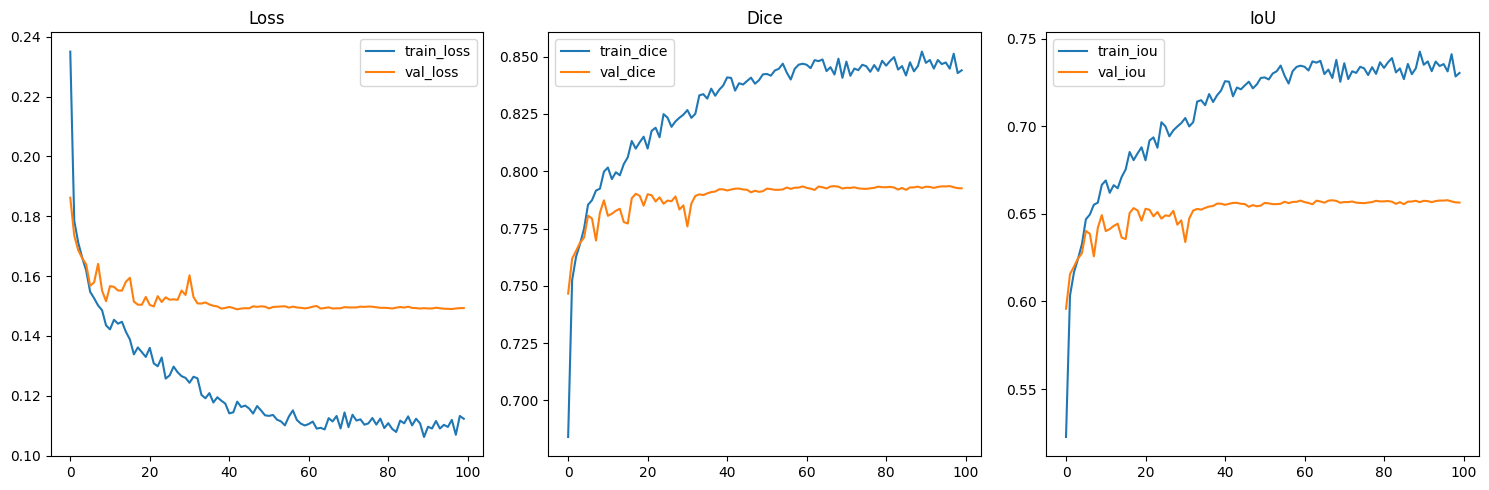

In [40]:
plot_lines(
    history,
    (["train_loss", "val_loss"], "Loss"),
    (["train_dice", "val_dice"], "Dice"),
    (["train_iou", "val_iou"], "IoU"),
)

Poniżej przykładowe próbki ze zbioru testowego.

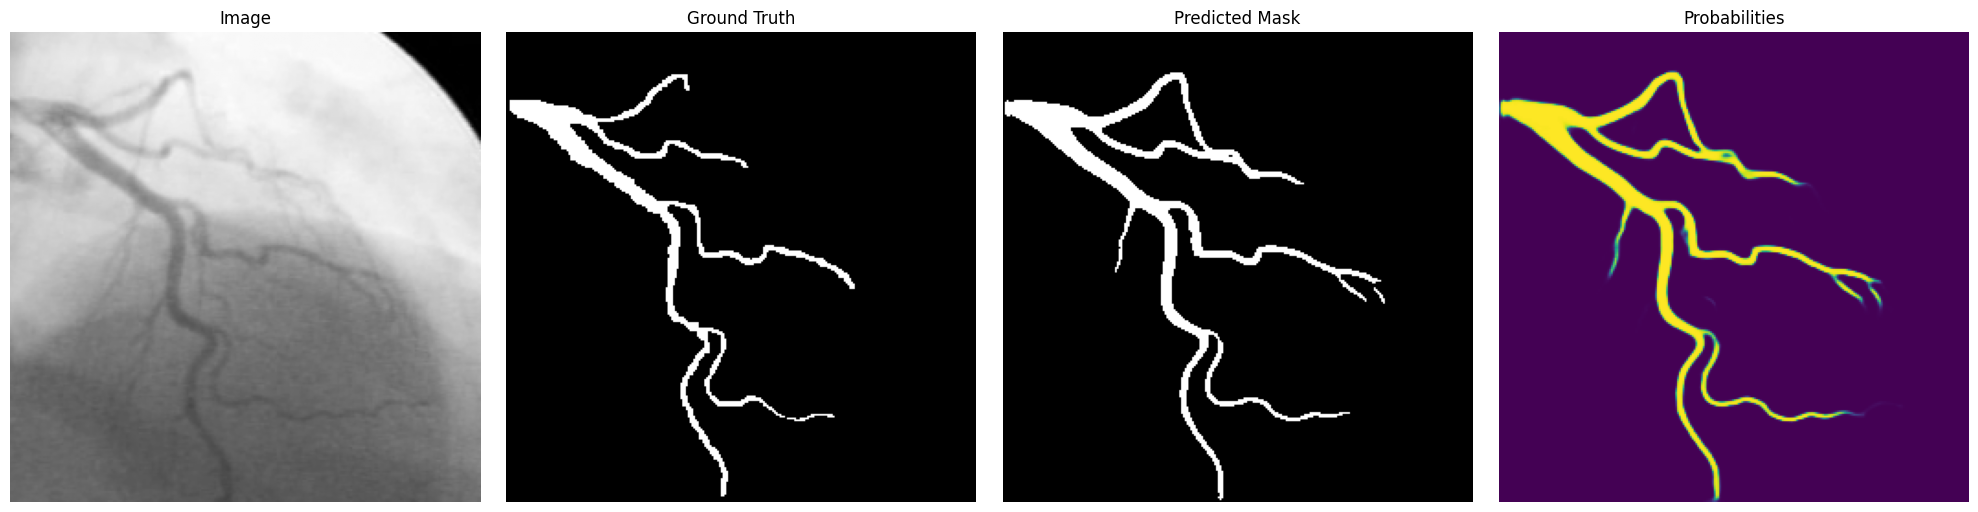

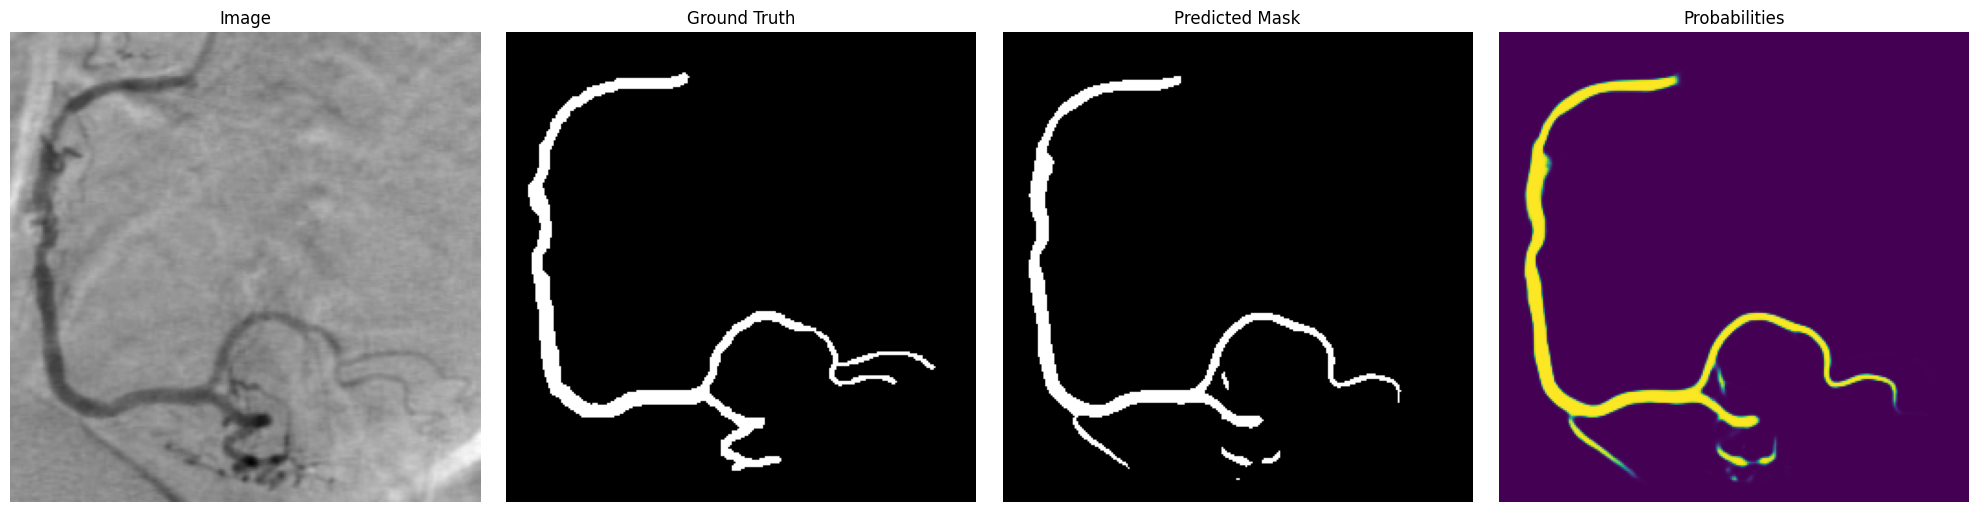

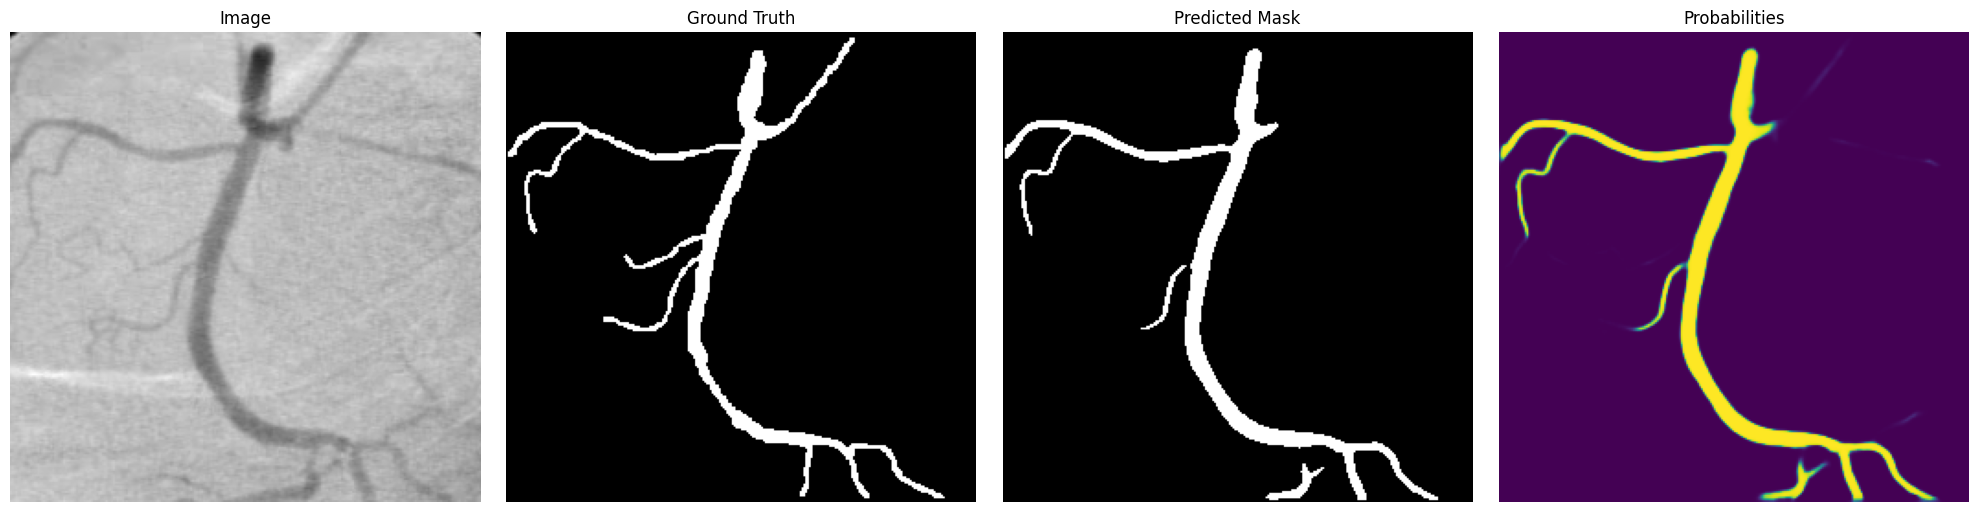

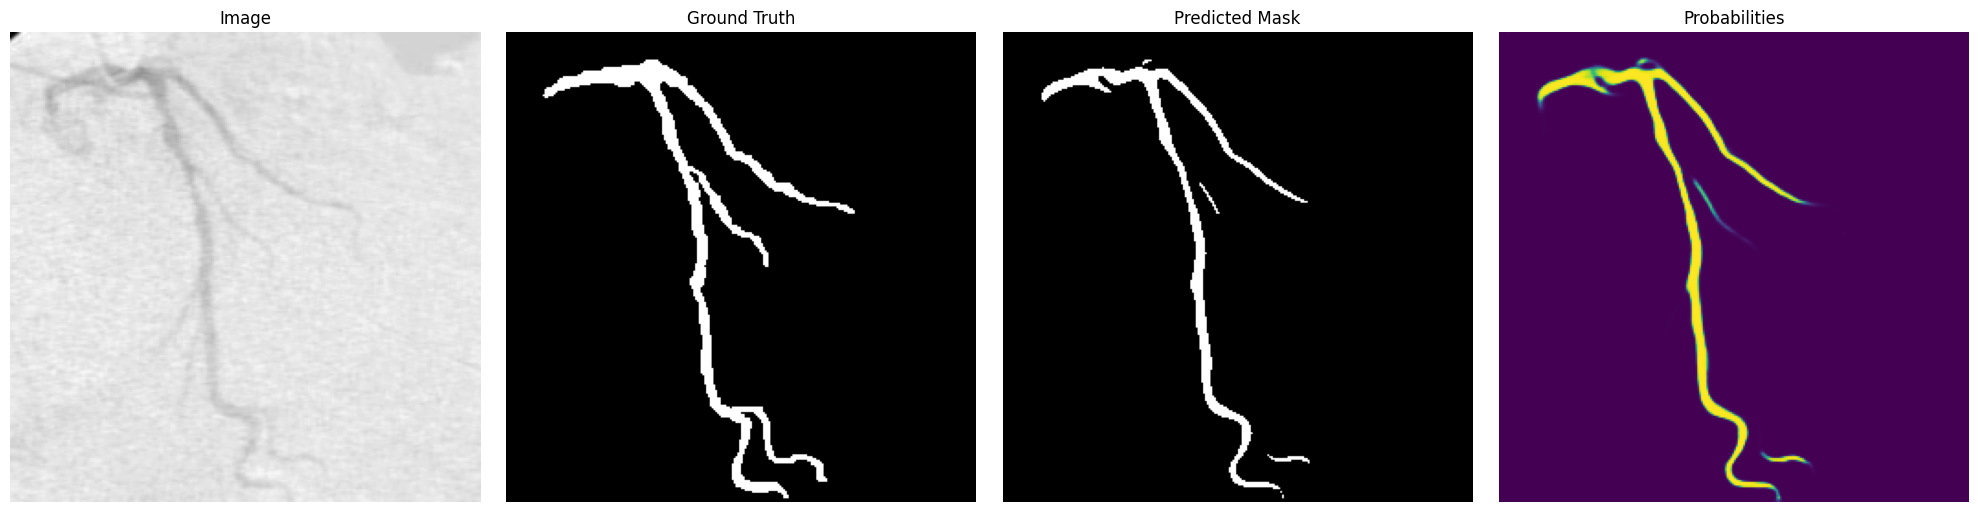

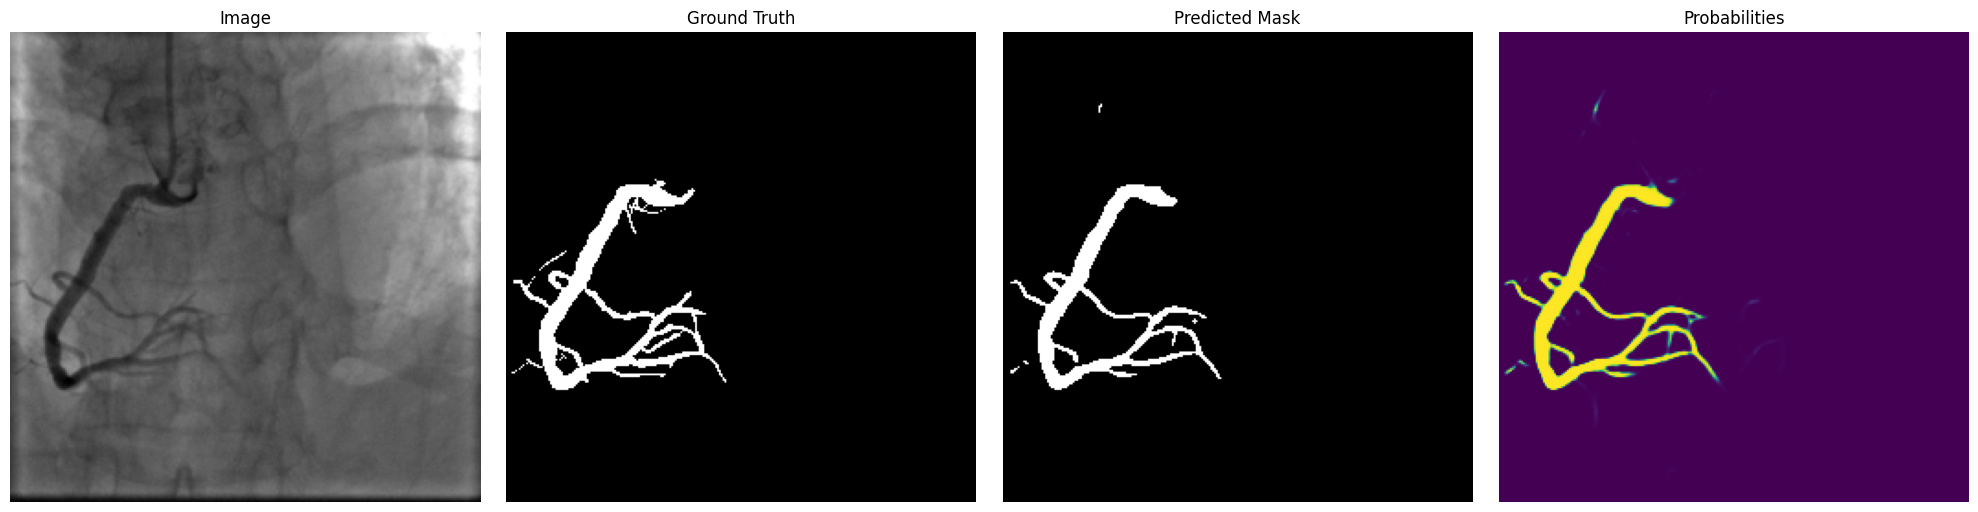

In [43]:
model.eval()

with torch.no_grad():
    test_loader_iter = iter(test_loader)

    images, masks = next(test_loader_iter)

    for i in range(min(5, len(images))):
        image = images[i].to(device)
        mask = masks[i].to(device)

        probs = model.predict_proba(image.unsqueeze(0))
        preds = (probs > 0.5).float()

        show_image(
            image[0].cpu().numpy(),
            mask[0].cpu().numpy(),
            preds[0, 0].cpu().numpy(),
            probs[0, 0].cpu().numpy(),
            titles=["Image", "Ground Truth", "Predicted Mask", "Probabilities"],
            cmap=["gray", "gray", "gray", None],
        )

Finalny wynik metryk dla zbioru testowego.

In [44]:
test_metrics = validate(test_loader, criterion, model)
print(
    f"Test Dice: {test_metrics[0]:.4f}, Test IoU: {test_metrics[1]:.4f}, Test Loss: {test_metrics[2]:.4f}"
)

Test Dice: 0.7924, Test IoU: 0.6563, Test Loss: 0.1489


## Przykładowe predykcje z ARCADE

In [50]:
arcade_test_ds = ArcadeSyntaxBinaryDataset(
    root="raw_datasets/arcade/arcade/syntax",
    split="test",
    transform=get_val_transforms(selected_params["img_size"]),
)

arcade_test_loader = DataLoader(
    arcade_test_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    persistent_workers=True,
)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


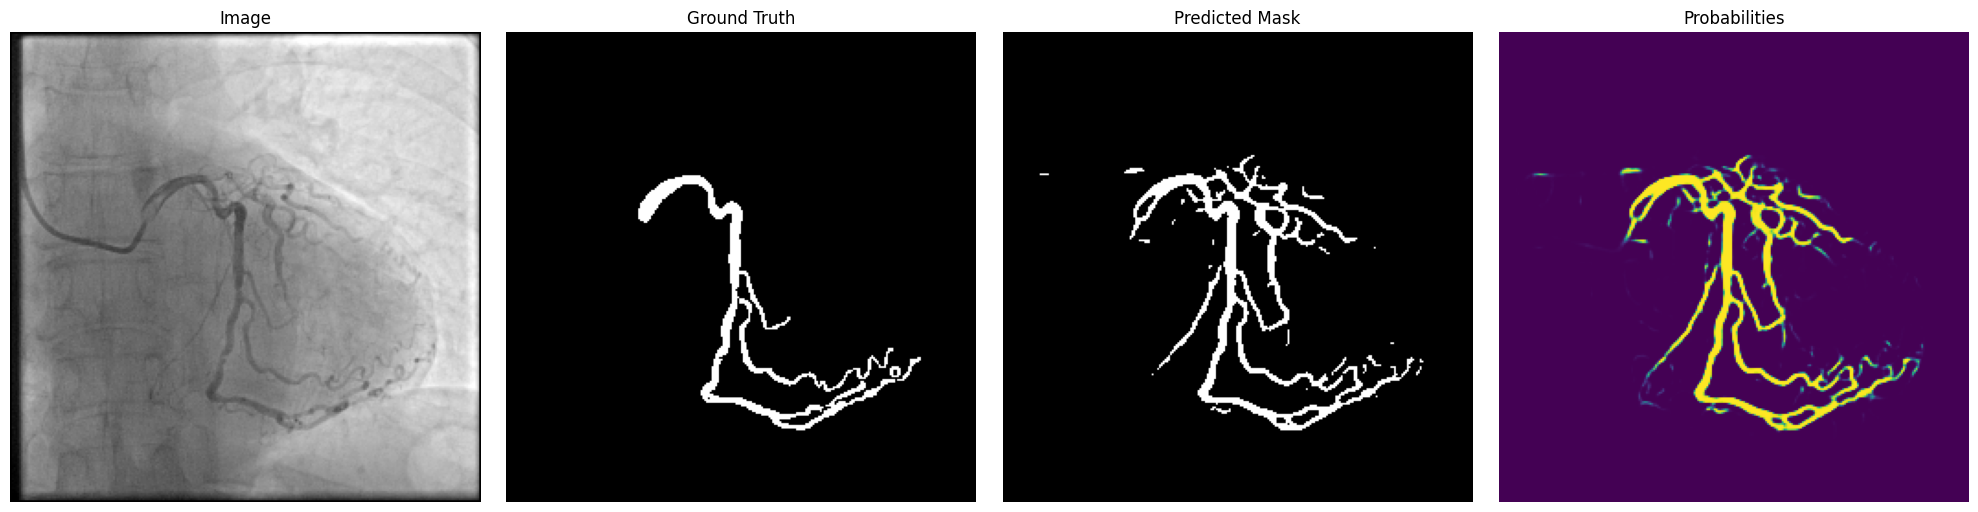

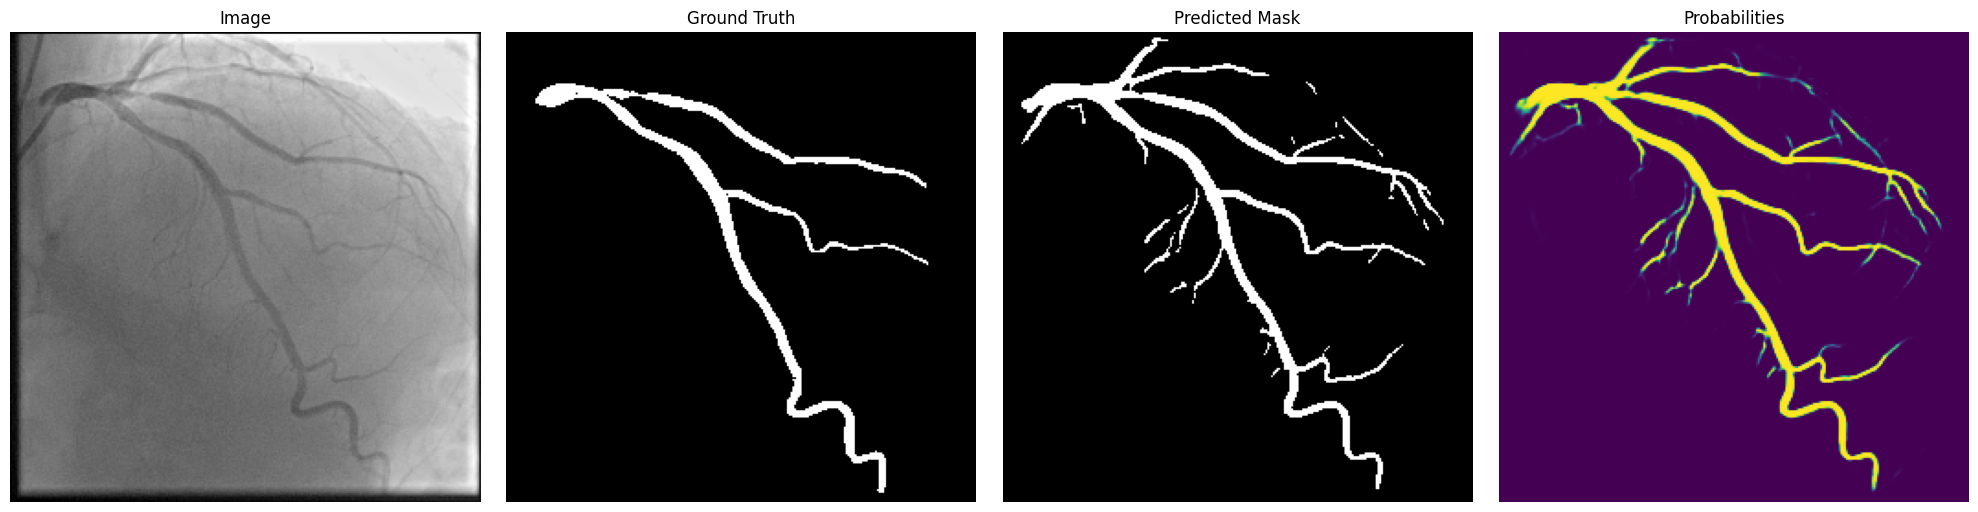

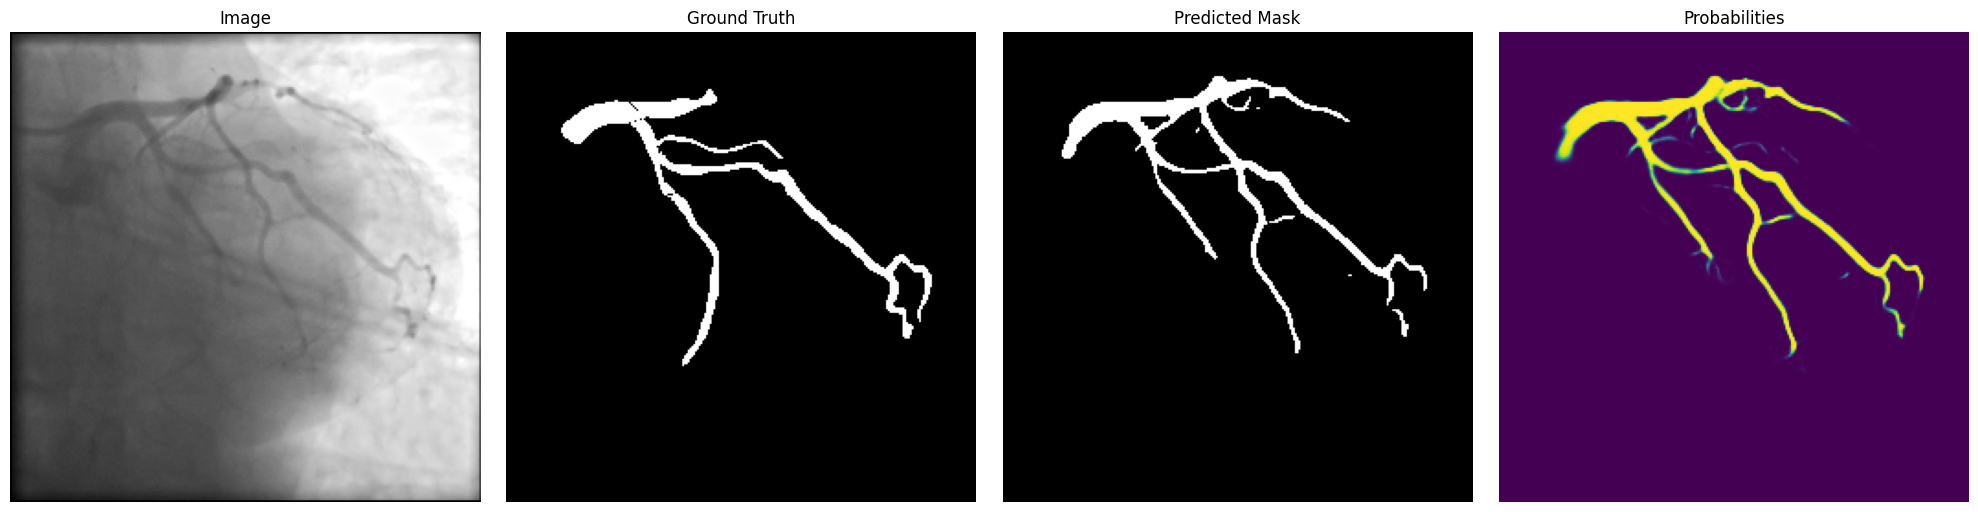

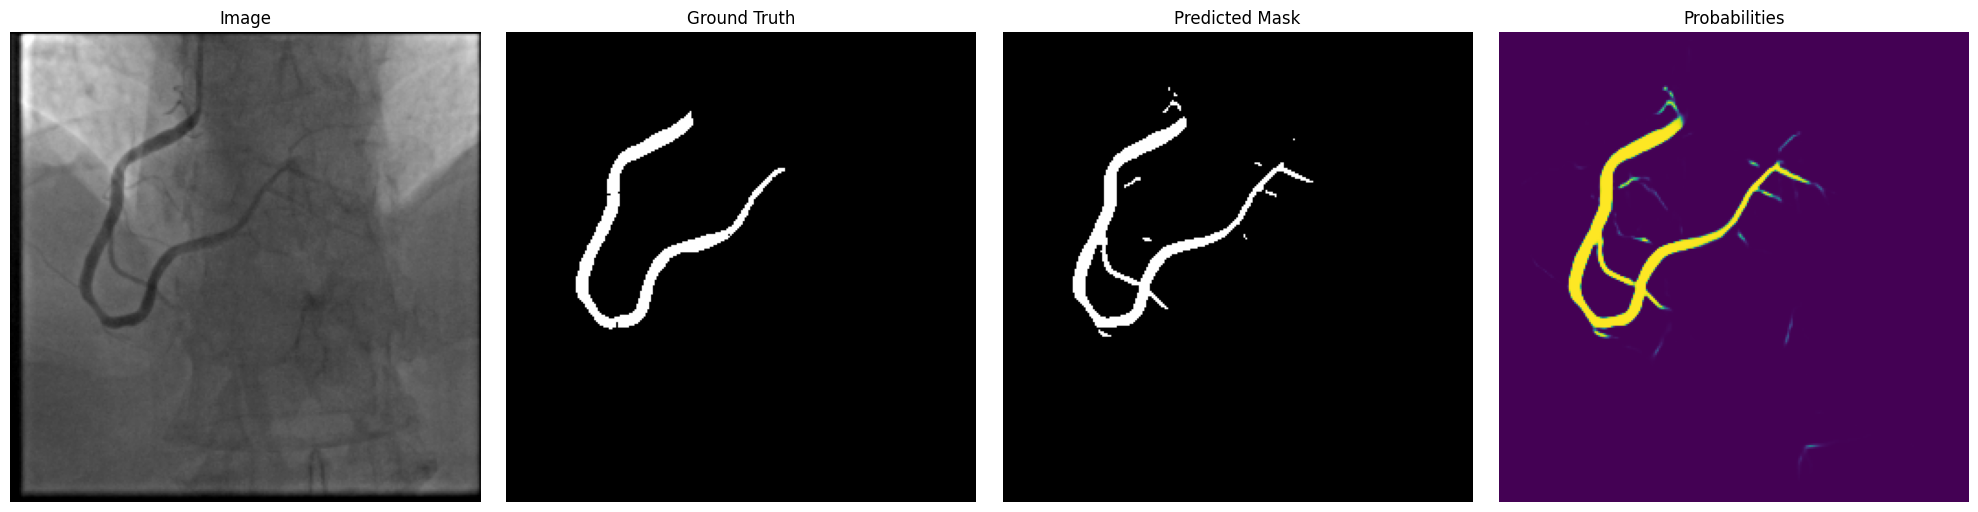

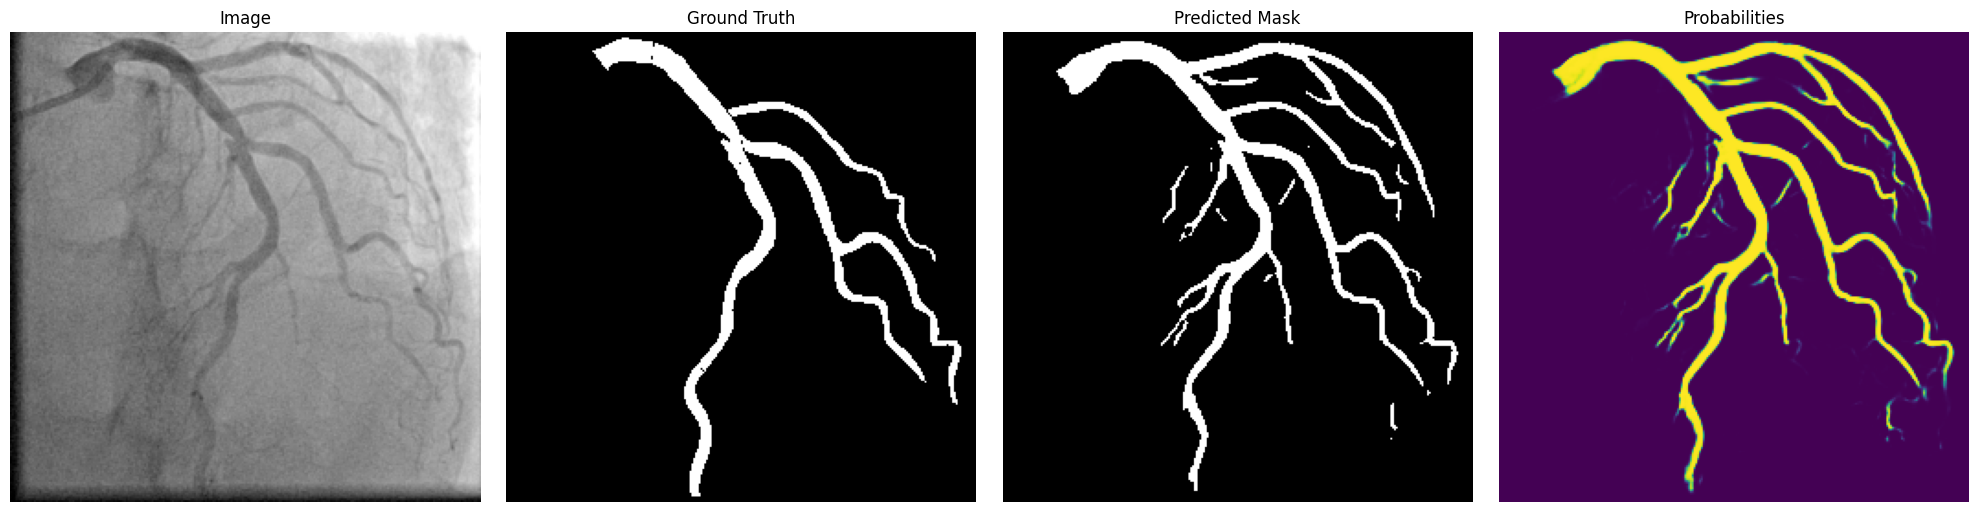

In [51]:
model.eval()

with torch.no_grad():
    arcade_test_loader_iter = iter(arcade_test_loader)

    for _ in range(5):
        image, mask = next(arcade_test_loader_iter)
        image = image.to(device)
        mask = mask.to(device)

        probs = model.predict_proba(image)
        preds = (probs > 0.5).float()

        show_image(
            image[0, 0].cpu().numpy(),
            mask[0, 0].cpu().numpy(),
            preds[0, 0].cpu().numpy(),
            probs[0, 0].cpu().numpy(),
            titles=["Image", "Ground Truth", "Predicted Mask", "Probabilities"],
            cmap=["gray", "gray", "gray", None],
        )

Ground truth above is not directly comparable to our predictions, as it is based on a different annotation protocol, but we can still see that the model is able to capture the general shape of the vessels and the stenosis.

In [52]:
if not os.path.exists("../models"):
    os.makedirs("../models")

torch.save(model.state_dict(), "../models/best_segmentation_model.pth")